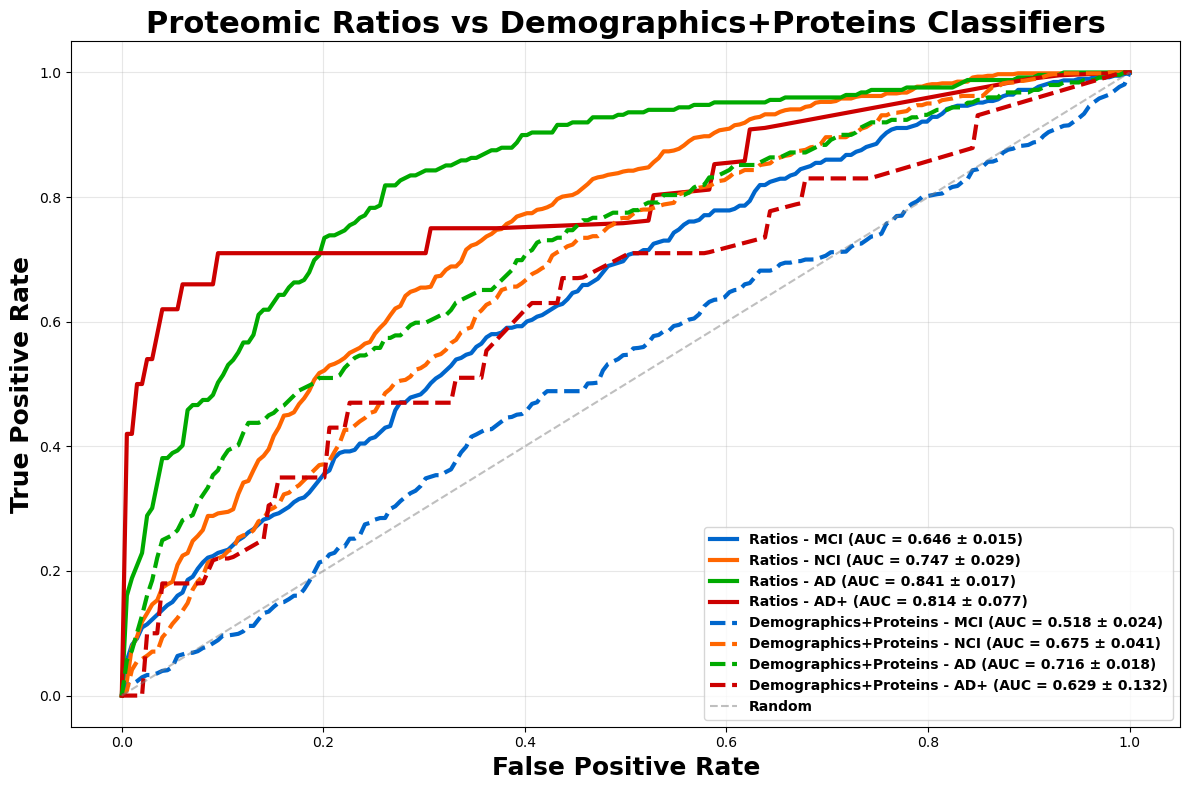

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- Config ---
ratios_dir = "/Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE"
baseline_dir = "/Users/adithyamadduri/Desktop/Projects/proteomics_LGBM(ANML+Meta)_fixed"
classes = ["MCI", "NCI", "AD", "AD+"]
seeds = [1, 2, 3, 4, 5]

# Define more contrasting colors for each class
class_colors = {
    "MCI": "#0066CC",    # bright blue
    "NCI": "#FF6600",    # bright orange
    "AD": "#00AA00",     # bright green
    "AD+": "#CC0000"     # bright red
}

def safe_cls(c):
    return c.replace("+", "plus").replace(" ", "_").replace("/", "-")

# --- ROC Plotting ---
fpr_grid = np.linspace(0.0, 1.0, 200)
plt.figure(figsize=(12, 8))

# Plot Proteomic Ratios
for cls in classes:
    tprs = []
    aucs = []

    for seed in seeds:
        file_path = os.path.join(ratios_dir, f"seed{seed}_{safe_cls(cls)}.csv")
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)
        fpr, tpr, _ = roc_curve(df["y_true"], df["y_score"])
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

    if not tprs:
        continue

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(fpr_grid, mean_tpr, label=f"Ratios - {cls} (AUC = {mean_auc:.3f} ± {std_auc:.3f})", 
             linewidth=3, color=class_colors[cls])

# Plot Demographics + Proteins
for cls in classes:
    tprs = []
    aucs = []

    for seed in seeds:
        file_path = os.path.join(baseline_dir, f"seed{seed}_{safe_cls(cls)}.csv")
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)
        fpr, tpr, _ = roc_curve(df["y_true"], df["y_score"])
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

    if not tprs:
        continue

    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(fpr_grid, mean_tpr, label=f"Demographics+Proteins - {cls} (AUC = {mean_auc:.3f} ± {std_auc:.3f})", 
             linewidth=3, linestyle="--", color=class_colors[cls])

# --- Finalize plot ---
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5, label="Random")
plt.xlabel("False Positive Rate", fontsize=18, fontweight='bold')
plt.ylabel("True Positive Rate", fontsize=18, fontweight='bold')
plt.title("Proteomic Ratios vs Demographics+Proteins Classifiers", fontsize=22, fontweight='bold')
plt.legend(loc="lower right", fontsize=12, prop={'weight': 'bold'})
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

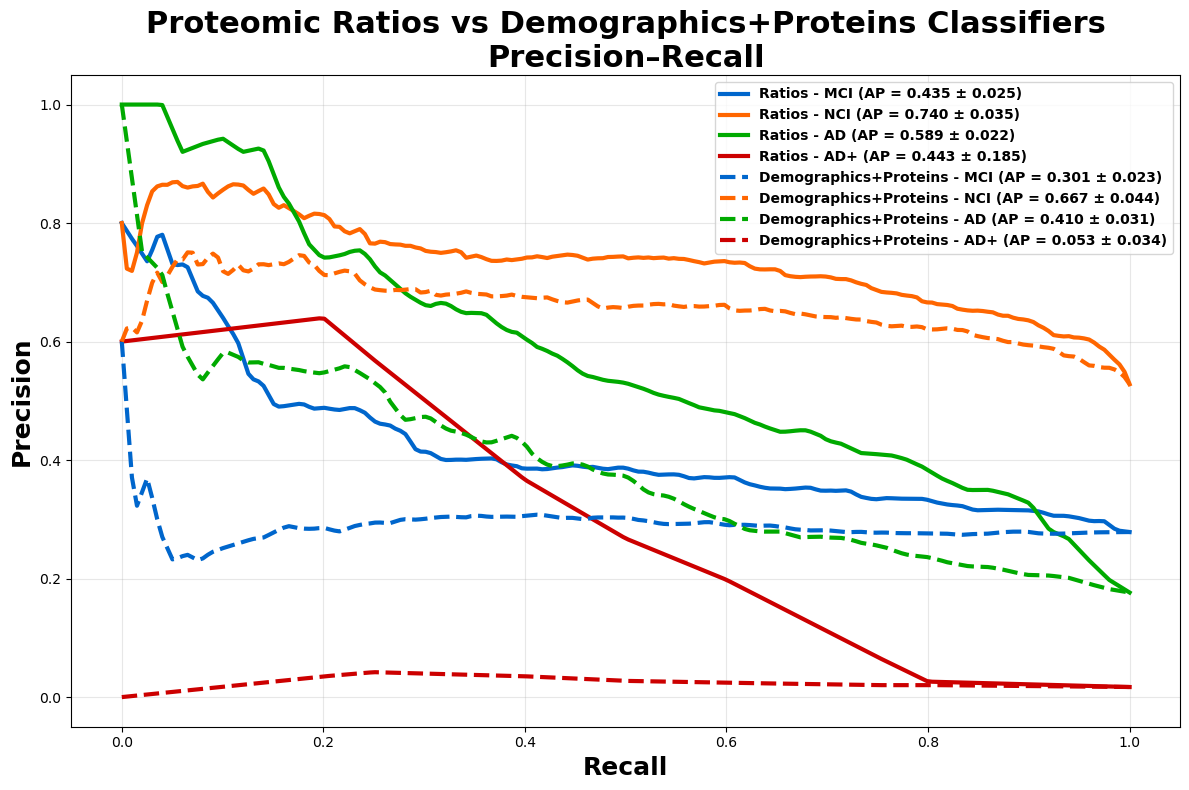

In [2]:
import os, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# ====== CONFIG ======
ratios_dir = "/Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE"
baseline_dir = "/Users/adithyamadduri/Desktop/Projects/proteomics_LGBM(ANML+Meta)_fixed"
classes = ["MCI", "NCI", "AD", "AD+"]

# Define more contrasting colors for each class
class_colors = {
    "MCI": "#0066CC",    # bright blue
    "NCI": "#FF6600",    # bright orange
    "AD": "#00AA00",     # bright green
    "AD+": "#CC0000"     # bright red
}

def safe_cls(c):
    return c.replace("+", "plus").replace(" ", "_").replace("/", "-")

recall_grid = np.linspace(0.0, 1.0, 200)

plt.figure(figsize=(12, 8))

# Plot Proteomic Ratios
for cls in classes:
    prec_interp_list, aps = [], []
    cls_name = safe_cls(cls)
    
    for seed in [1, 2, 3, 4, 5]:
        path = os.path.join(ratios_dir, f"seed{seed}_{cls_name}.csv")
        if not os.path.exists(path):
            continue
            
        df = pd.read_csv(path)
        y_true = df["y_true"].astype(int).values
        y_score = df["y_score"].astype(float).values

        # PR curve
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        # Deduplicate recall for interpolation
        uniq_idx = np.unique(recall, return_index=True)[1]
        r_u, p_u = recall[uniq_idx], precision[uniq_idx]

        # Interpolate precision onto a common recall grid
        p_i = np.interp(recall_grid, r_u, p_u, left=p_u[0], right=p_u[-1])
        prec_interp_list.append(p_i)
        aps.append(average_precision_score(y_true, y_score))

    if not prec_interp_list:
        continue

    mean_prec = np.mean(prec_interp_list, axis=0)
    mean_ap = float(np.mean(aps))
    std_ap = float(np.std(aps))

    # Plot PR curve
    plt.plot(recall_grid, mean_prec, lw=3, color=class_colors[cls],
             label=f"Ratios - {cls} (AP = {mean_ap:.3f} ± {std_ap:.3f})")

# Plot Demographics + Proteins
for cls in classes:
    prec_interp_list, aps = [], []
    cls_name = safe_cls(cls)
    
    for seed in [1, 2, 3, 4, 5]:
        path = os.path.join(baseline_dir, f"seed{seed}_{cls_name}.csv")
        if not os.path.exists(path):
            continue
            
        df = pd.read_csv(path)
        y_true = df["y_true"].astype(int).values
        y_score = df["y_score"].astype(float).values

        # PR curve
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        # Deduplicate recall for interpolation
        uniq_idx = np.unique(recall, return_index=True)[1]
        r_u, p_u = recall[uniq_idx], precision[uniq_idx]

        # Interpolate precision onto a common recall grid
        p_i = np.interp(recall_grid, r_u, p_u, left=p_u[0], right=p_u[-1])
        prec_interp_list.append(p_i)
        aps.append(average_precision_score(y_true, y_score))

    if not prec_interp_list:
        continue

    mean_prec = np.mean(prec_interp_list, axis=0)
    mean_ap = float(np.mean(aps))
    std_ap = float(np.std(aps))

    # Plot PR curve (dashed)
    plt.plot(recall_grid, mean_prec, lw=3, linestyle="--", color=class_colors[cls],
             label=f"Demographics+Proteins - {cls} (AP = {mean_ap:.3f} ± {std_ap:.3f})")

plt.xlabel('Recall', fontsize=18, fontweight='bold')
plt.ylabel('Precision', fontsize=18, fontweight='bold')
plt.title("Proteomic Ratios vs Demographics+Proteins Classifiers\nPrecision–Recall", fontsize=22, fontweight='bold')
plt.legend(loc='upper right', fontsize=12, prop={'weight': 'bold'})
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

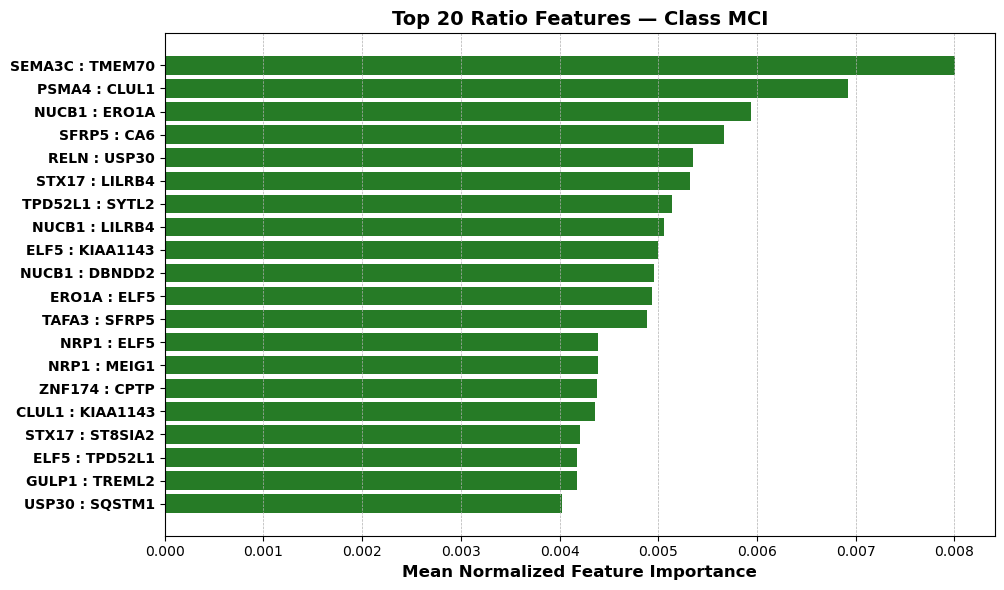

Saved: /Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE/top20_ratios_MCI.png


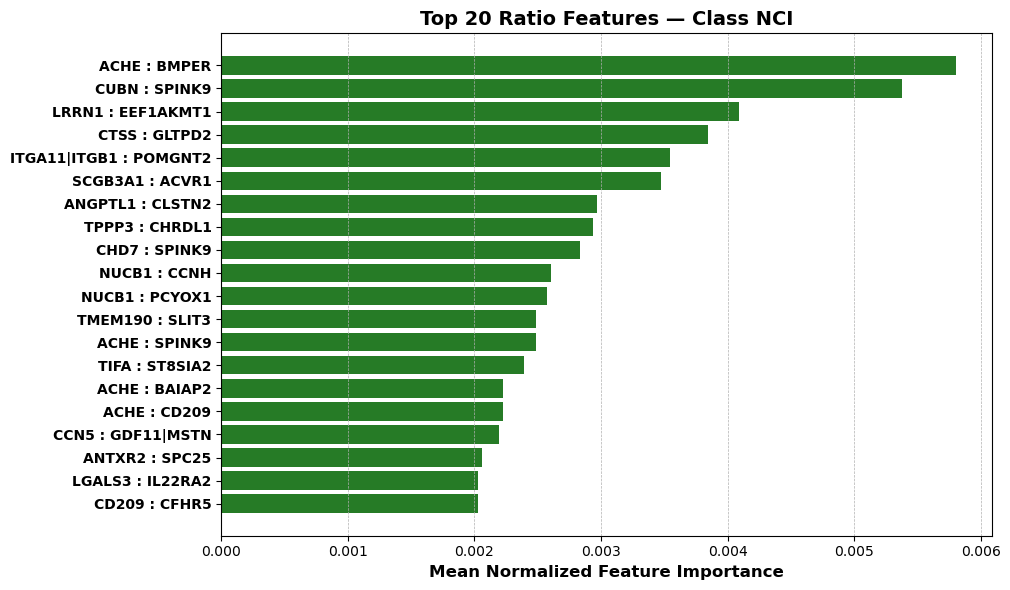

Saved: /Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE/top20_ratios_NCI.png


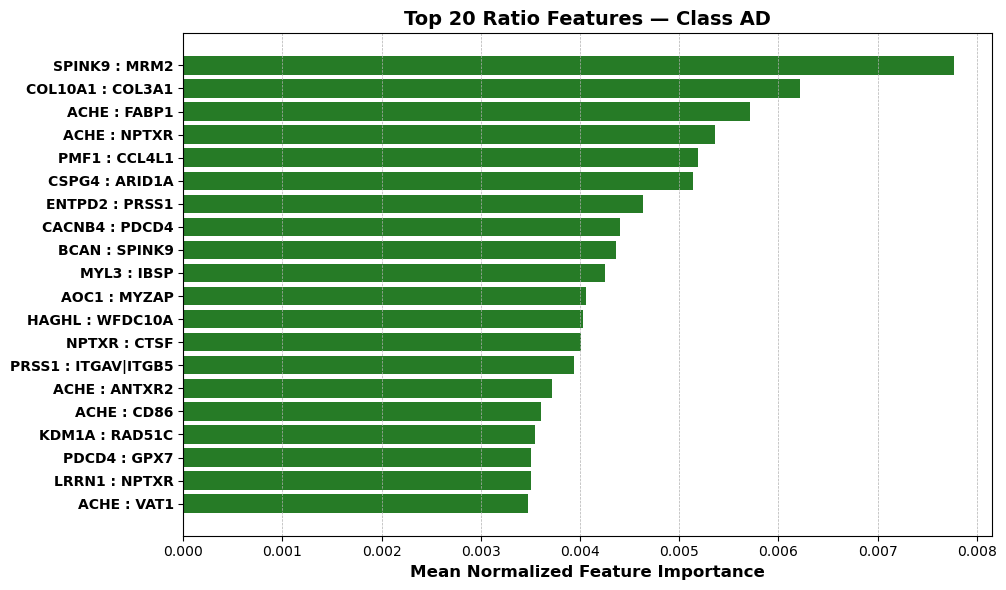

Saved: /Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE/top20_ratios_AD.png


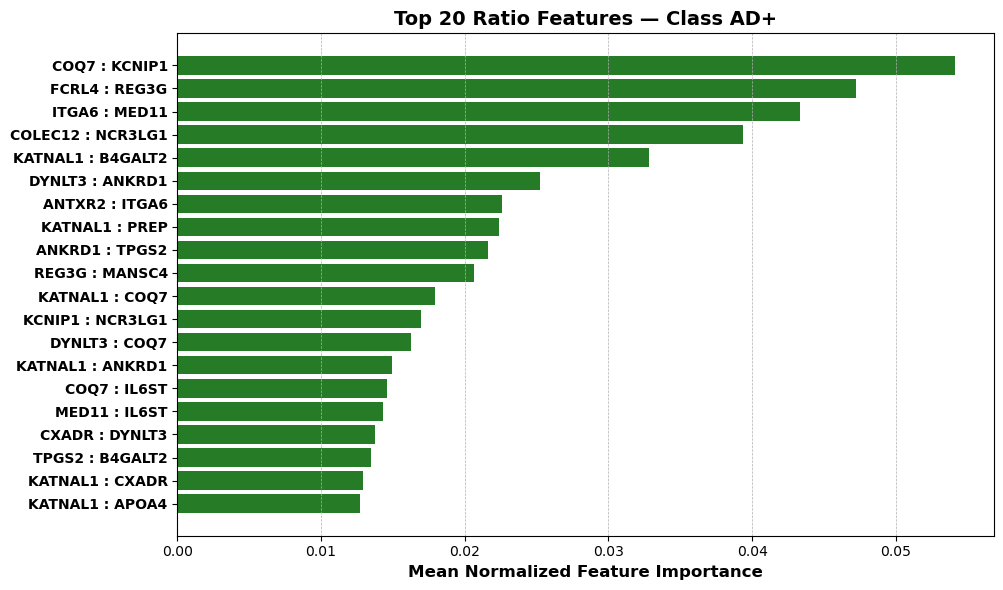

Saved: /Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE/top20_ratios_ADplus.png


In [4]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIG ===
out_dir = "/Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE"
protein_metadata_path = "/Users/adithyamadduri/Downloads/syn65414912/OhNM2025_ROSMAP_plasma_Soma7k_protein_metadata.csv"

classes = ["MCI", "NCI", "AD", "AD+"]
seeds = [1, 2, 3, 4, 5]
top_n = 20  # number of top features to display

# ---- Load SeqId → GeneSymbol mapping ----
df_meta = pd.read_csv(protein_metadata_path)
seqid_to_gene = dict(zip(df_meta["SeqId"], df_meta["EntrezGeneSymbol"]))

def safe_cls(c):
    return c.replace("+", "plus").replace(" ", "_").replace("/", "-")

# ---- Helper: map ratio feature name to gene symbols ----
def map_ratio_name(name):
    if "_minus_" in name:
        left, right = name.split("_minus_")
        gene_left = seqid_to_gene.get(left, left)
        gene_right = seqid_to_gene.get(right, right)
        return f"{gene_left} : {gene_right}"
    elif "_div_" in name:  # Support old naming convention for backwards compatibility
        left, right = name.split("_div_")
        gene_left = seqid_to_gene.get(left, left)
        gene_right = seqid_to_gene.get(right, right)
        return f"{gene_left} : {gene_right}"
    return seqid_to_gene.get(name, name)

# === MAIN LOOP ===
for cls in classes:
    feature_importance_list = []

    for seed in seeds:
        pkl_path = os.path.join(out_dir, f"seed{seed}_{safe_cls(cls)}_automl.pkl")
        if not os.path.exists(pkl_path):
            print(f"Missing: {pkl_path}")
            continue

        with open(pkl_path, "rb") as f:
            automl = pickle.load(f)

        model = automl.model.estimator
        importances = model.feature_importances_
        features = automl.feature_names_in_

        # Normalize importance
        norm_importance = importances / importances.sum()
        feature_importance_list.append(pd.Series(norm_importance, index=features))

    if not feature_importance_list:
        print(f"No data for class: {cls}")
        continue

    # Combine across seeds
    df_importances = pd.concat(feature_importance_list, axis=1)
    df_importances.columns = [f"seed{i}" for i in range(len(df_importances.columns))]

    # Compute mean across seeds
    df_importances["mean"] = df_importances.mean(axis=1)

    # Take top N
    df_top = df_importances.sort_values("mean", ascending=False).head(top_n)

    # Map feature names
    df_top["mapped_name"] = df_top.index.map(map_ratio_name)

    # === Plot ===
    plt.figure(figsize=(10, max(6, 0.3 * top_n)))
    plt.barh(y=df_top["mapped_name"][::-1], width=df_top["mean"][::-1], color="darkgreen", alpha=0.85)

    plt.xlabel("Mean Normalized Feature Importance", fontsize=12, fontweight='bold')
    plt.title(f"Top {top_n} Ratio Features — Class {cls}", fontsize=14, fontweight='bold')
    plt.tick_params(axis='y', labelsize=10)
    plt.tight_layout()
    plt.grid(True, axis="x", linestyle="--", linewidth=0.5)
    
    # Make y-axis labels bold
    ax = plt.gca()
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    # Save plot
    plot_path = os.path.join(out_dir, f"top{top_n}_ratios_{safe_cls(cls)}.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()

    print(f"Saved: {plot_path}")

In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    roc_curve, precision_recall_curve, auc
)

# ====== CONFIG ======
ratios_dir = "/Users/adithyamadduri/Desktop/Projects/ratios_project/Revision/Results/Protein_ratios_noRFE"
baseline_dirs = [
    "/Users/adithyamadduri/Desktop/Projects/proteomics_LGBM(ANML+Meta)_BASELINE_demo_only",
    "/Users/adithyamadduri/Desktop/Projects/proteomics_LGBM(ANML+Meta)_BASELINE_random",
    "/Users/adithyamadduri/Desktop/Projects/proteomics_LGBM(ANML+Meta)_fixed"
]

model_names = [
    "Proteomic Ratios",
    "Demographics Only Baseline",
    "Stratified Random Baseline",
    "Raw Proteins + Demographics"
]

classes = ["MCI", "NCI", "AD", "AD+"]
seeds = [1, 2, 3, 4, 5]

def safe_cls(c):
    return c.replace("+", "plus").replace(" ", "_").replace("/", "-")


# ===============================
# METRICS SUMMARY (AUROC + AP)
# ===============================

def load_seed_df(folder, seed, cls):
    path = os.path.join(folder, f"seed{seed}_{safe_cls(cls)}.csv")
    if not os.path.exists(path):
        return None, path

    df = pd.read_csv(path)

    # --- Required columns ---
    required = ["y_true", "y_score"]
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {path}. Found: {list(df.columns)}")

    # Clean types
    df = df.copy()
    df["y_true"] = df["y_true"].astype(int)
    df["y_score"] = df["y_score"].astype(float)

    return df, path


def compute_metrics(df):
    y_true = df["y_true"].values
    y_score = df["y_score"].values

    # Guard: roc_auc_score fails if only one class present
    if len(np.unique(y_true)) < 2:
        return {
            "auc": np.nan,
            "ap": np.nan,
            "n": len(y_true),
            "pos_rate": float(np.mean(y_true))
        }

    auc_val = roc_auc_score(y_true, y_score)
    ap_val = average_precision_score(y_true, y_score)

    return {
        "auc": float(auc_val),
        "ap": float(ap_val),
        "n": len(y_true),
        "pos_rate": float(np.mean(y_true))
    }


# ---- Run all models ----
all_dirs = [ratios_dir] + baseline_dirs

if len(all_dirs) != len(model_names):
    raise ValueError("model_names length must match number of dirs (ratios_dir + baseline_dirs).")

results_rows = []

for model_name, folder in zip(model_names, all_dirs):
    for cls in classes:
        for seed in seeds:
            df, path = load_seed_df(folder, seed, cls)
            if df is None:
                print(f"[WARN] Missing: {path}")
                continue

            m = compute_metrics(df)

            results_rows.append({
                "model": model_name,
                "class": cls,
                "seed": seed,
                "auc": m["auc"],
                "ap": m["ap"],
                "n": m["n"],
                "pos_rate": m["pos_rate"],
                "file": path
            })

results_df = pd.DataFrame(results_rows)

# ---- Sanity checks ----
if results_df.empty:
    raise ValueError("No results loaded. Check paths and filenames.")

print("\nLoaded results:")
print(results_df.groupby(["model", "class"])["seed"].count().unstack(fill_value=0))


# ---- Summary: mean ± std ----
summary = (
    results_df
    .groupby(["model", "class"])
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        ap_mean=("ap", "mean"),
        ap_std=("ap", "std"),
        n_mean=("n", "mean"),
        pos_rate_mean=("pos_rate", "mean"),
        seeds=("seed", "count")
    )
    .reset_index()
)

# Sort in the order you want
summary["model"] = pd.Categorical(summary["model"], categories=model_names, ordered=True)
summary["class"] = pd.Categorical(summary["class"], categories=classes, ordered=True)
summary = summary.sort_values(["model", "class"]).reset_index(drop=True)

print("\n==============================")
print("SUMMARY: AUROC and AP (mean ± std)")
print("==============================")
for cls in classes:
    print(f"\n--- {cls} ---")
    sub = summary[summary["class"] == cls]
    for _, r in sub.iterrows():
        print(
            f"{r['model']:<30} "
            f"AUC = {r['auc_mean']:.4f} ± {r['auc_std']:.4f} | "
            f"AP = {r['ap_mean']:.4f} ± {r['ap_std']:.4f} | "
            f"n≈{int(round(r['n_mean']))} | pos_rate≈{r['pos_rate_mean']:.3f} | seeds={int(r['seeds'])}"
        )


# ---- Compute deltas vs chosen baseline ----
def delta_table(metric="auc", ref_model="Raw Proteins + Demographics"):
    pivot = summary.pivot(index="class", columns="model", values=f"{metric}_mean")

    if ref_model not in pivot.columns:
        raise ValueError(f"Reference model '{ref_model}' not found in summary columns: {list(pivot.columns)}")

    deltas = pivot.subtract(pivot[ref_model], axis=0)
    deltas = deltas.loc[classes, model_names]  # enforce ordering
    return deltas


auc_deltas = delta_table(metric="auc", ref_model="Raw Proteins + Demographics")
ap_deltas  = delta_table(metric="ap",  ref_model="Raw Proteins + Demographics")

print("\n==============================")
print("Δ AUROC vs Raw Proteins + Demographics (mean over seeds)")
print("==============================")
print(auc_deltas.round(4))

print("\n==============================")
print("Δ AP vs Raw Proteins + Demographics (mean over seeds)")
print("==============================")
print(ap_deltas.round(4))


# ---- Average deltas across the 4 classes ----
def mean_delta_across_classes(metric="auc", model="Proteomic Ratios", ref_model="Raw Proteins + Demographics"):
    pivot = summary.pivot(index="class", columns="model", values=f"{metric}_mean")
    return float((pivot[model] - pivot[ref_model]).mean())

for ref in ["Raw Proteins + Demographics", "Demographics Only Baseline", "Stratified Random Baseline"]:
    d_auc = mean_delta_across_classes(metric="auc", model="Proteomic Ratios", ref_model=ref)
    d_ap  = mean_delta_across_classes(metric="ap",  model="Proteomic Ratios", ref_model=ref)
    print("\n==============================")
    print(f"Proteomic Ratios improvement vs {ref}")
    print("==============================")
    print(f"Mean ΔAUROC across classes = {d_auc:+.4f}")
    print(f"Mean ΔAP across classes    = {d_ap:+.4f}")


# ---- Save tables for LaTeX copy/paste ----
out_csv = os.path.join(ratios_dir, "metric_summary_all_models.csv")
summary.to_csv(out_csv, index=False)
print(f"\nSaved summary table to: {out_csv}")



Loaded results:
class                        AD  AD+  MCI  NCI
model                                         
Demographics Only Baseline    5    5    5    5
Proteomic Ratios              5    5    5    5
Raw Proteins + Demographics   5    5    5    5
Stratified Random Baseline    5    5    5    5

SUMMARY: AUROC and AP (mean ± std)

--- MCI ---
Proteomic Ratios               AUC = 0.6457 ± 0.0170 | AP = 0.4348 ± 0.0274 | n≈282 | pos_rate≈0.279 | seeds=5
Demographics Only Baseline     AUC = 0.5508 ± 0.0070 | AP = 0.3349 ± 0.0144 | n≈282 | pos_rate≈0.279 | seeds=5
Stratified Random Baseline     AUC = 0.5195 ± 0.0212 | AP = 0.3067 ± 0.0206 | n≈282 | pos_rate≈0.279 | seeds=5
Raw Proteins + Demographics    AUC = 0.5176 ± 0.0268 | AP = 0.3011 ± 0.0258 | n≈282 | pos_rate≈0.279 | seeds=5

--- NCI ---
Proteomic Ratios               AUC = 0.7469 ± 0.0321 | AP = 0.7398 ± 0.0389 | n≈282 | pos_rate≈0.528 | seeds=5
Demographics Only Baseline     AUC = 0.6447 ± 0.0272 | AP = 0.6555 ± 0.0324 | n≈282 